In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"d:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-10\insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


1.画出因变量charges分布的直方图，以验证其分布是否为正态分布

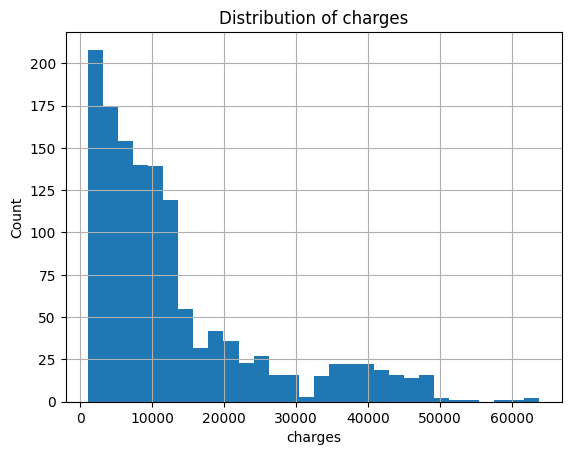

In [2]:
df['charges'].hist(bins=30)
plt.title('Distribution of charges')
plt.xlabel('charges')
plt.ylabel('Count')
plt.show()
# charges的分布不是正态分布。它呈现出明显的右偏分布特征

2.画出非数值类型特征“sex”、“smoker”以及“region”各自的频数分布图。画出“sex”与“smoker”间的散点气泡图。

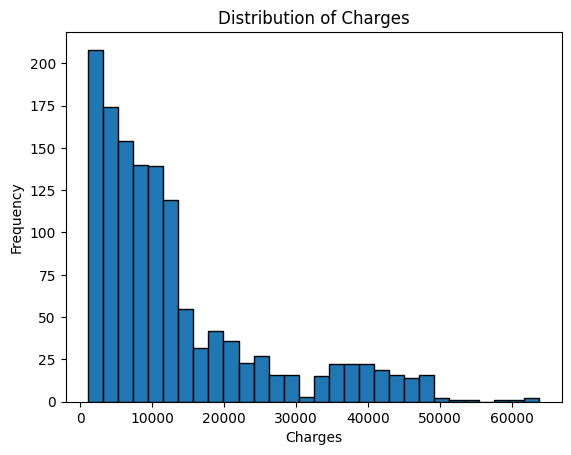

In [19]:
import matplotlib.pyplot as plt

# 绘制 'charges' 的直方图
df['charges'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

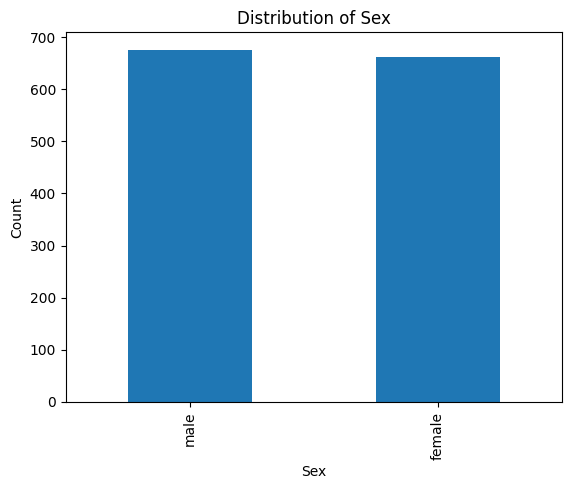

In [3]:
df['sex'].value_counts().plot(kind='bar')
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

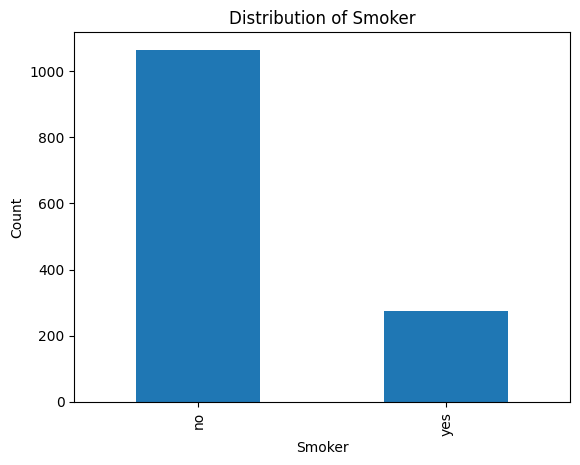

In [4]:
df['smoker'].value_counts().plot(kind='bar')
plt.title('Distribution of Smoker')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

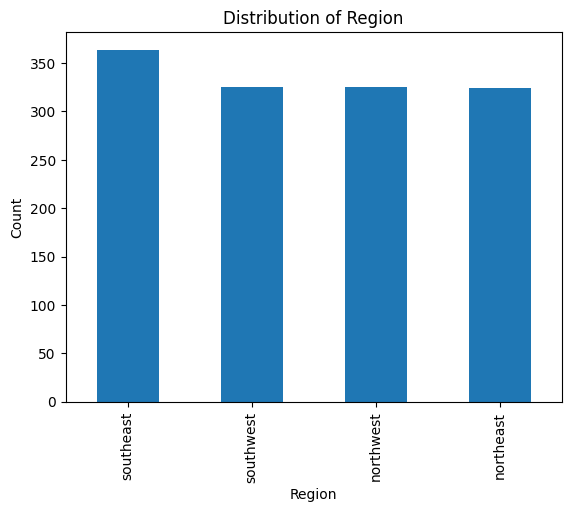

In [5]:
df['region'].value_counts().plot(kind='bar')
plt.title('Distribution of Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()


3.计算数值类型特征“age”、“bmi”、“children”以及“charges”之间的相关系数矩阵。

In [13]:
df[['age','bmi','children','charges']].corr()


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


4.对3个非数值类型特征进行顺序编码。

In [7]:
df['sex'] = df['sex'].map({'male':0,'female':1})
df['smoker'] = df['smoker'].map({'yes':1,'no':0})
df['region'] = df['region'].map({'southwest':0,'southeast':1,'northwest':2,'northeast':3})


5.建立线性回归模型，随机选取20%的数据作为测试集，80%的数据作为训练集，在测试集上计算性能评价指标（均方误差MSE以及决定系数R2）。要求分别用梯度下降法（自己编写函数，不能调用sklearn中的函数）和调用sklearn中封装好的函数来实现。

In [18]:
# 导入必要的库
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

# 准备数据
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 梯度下降法实现线性回归
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)
    for epoch in range(epochs):
        predictions = np.dot(X, theta)
        errors = predictions - y
        gradient = np.dot(X.T, errors) / m
        theta -= learning_rate * gradient
    return theta

# 使用梯度下降法训练模型
theta_gd = gradient_descent(X_train_scaled, y_train)

# 在测试集上进行预测
y_pred_gd = np.dot(X_test_scaled, theta_gd)

# 计算MSE和R2
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("梯度下降法结果：")
print(f"MSE: {mse_gd}")
print(f"R2: {r2_gd}")

# 使用sklearn实现线性回归
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 在测试集上进行预测
y_pred_sk = lr.predict(X_test_scaled)

# 计算MSE和R2
mse_sk = mean_squared_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

print("\nScikit-learn结果：")
print(f"MSE: {mse_sk}")
print(f"R2: {r2_sk}")

梯度下降法结果：
MSE: 205753872.30433145
R2: -0.32531757475412415

Scikit-learn结果：
MSE: 33635210.431178436
R2: 0.7833463107364537
